### 1 Setup

In [1]:
from pathlib import Path

import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, warnings, random, os

warnings.filterwarnings('ignore')
sys.path.append(str(Path("..").resolve()))

In [2]:
def seed_everything(seed=42):
    # 1. Standard Python & OS Level
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch CPU & GPU Core Seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # Safe to use even if you don't use multi-GPU
    
    # 3. cuDNN Backend Configurations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Reproducibility — fix random seeds for consistent results
SEED = 42
seed_everything(SEED)

In [3]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()

print(f"PyTorch version : {torch.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Device in use   : {device}")
print("\nSetup complete. You are ready to begin. ✓")

PyTorch version : 2.6.0+cu124
NumPy version   : 2.4.4
CUDA available  : True
Device in use   : cuda

Setup complete. You are ready to begin. ✓


In [4]:
DATA_DIR = Path.cwd().parent / "data/facebook-recruiting-iv-human-or-bot"

df_bids = pl.read_csv(DATA_DIR / "bids.csv")
df_train = pl.read_csv(DATA_DIR / "train.csv")
df_test = pl.read_csv(DATA_DIR / "test.csv")

In [5]:
df = df_bids.join(df_train, on="bidder_id", how="left") # get train data
df_labeled = df.filter(pl.col("outcome").is_not_null()) # filter test data

print("num of rows    :", df_labeled.shape[0])
print("num of columns :", df_labeled.shape[1])
print("num of bidders :", df_labeled.select('bidder_id').unique().shape[0])

num of rows    : 3071224
num of columns : 12
num of bidders : 1984


### 2 Data Preprocessing

In [6]:
time_diffs = (
    df_labeled.sort(["bidder_id", "auction", "time"])
    .with_columns(pl.col("time").diff().over(["bidder_id", "auction"]).alias("dt"))
    .filter(pl.col("dt").is_not_null())
)

dt_std = (
    time_diffs.group_by("bidder_id")
    .agg(pl.std("dt").alias("dt_std"))
    .join(df_train, on="bidder_id", how="left")
)

simul = (
    df_labeled.group_by(["bidder_id", "time"])
    .agg(pl.n_unique("auction").alias("n_auctions_same_ts"))
    .filter(pl.col("n_auctions_same_ts") > 1)
    .group_by("bidder_id")
    .agg(pl.len().alias("n_simultaneous"))
)

all_bidders = (
    df_train.select("bidder_id", "outcome")
    .join(simul, on="bidder_id", how="left")
    .with_columns(pl.col("n_simultaneous").fill_null(0))
)

per_bidder = (
    df_labeled.group_by("bidder_id")
    .agg(
        n_bids=pl.len(),
        n_auctions=pl.n_unique("auction"),
        n_ips=pl.n_unique("ip"),
        n_devices=pl.n_unique("device"),
        n_countries=pl.n_unique("country"),
        n_urls=pl.n_unique("url"),
        bids_per_auction=pl.len() / pl.n_unique("auction"),
        time_span=(pl.max("time") - pl.min("time")),
    )
    .join(dt_std.select("bidder_id", "dt_std"), on="bidder_id", how="left")
    .join(
        time_diffs.group_by("bidder_id").agg(
            pl.median("dt").alias("dt_self_median"),
            pl.min("dt").alias("dt_self_min"),
        ),
        on="bidder_id",
        how="left",
    )
    .join(
        all_bidders.select("bidder_id", "n_simultaneous"),
        on="bidder_id",
        how="left",
    )
    .join(df_train.select("bidder_id", "outcome"), on="bidder_id", how="left")
    .drop_nulls(subset=["outcome"])
)

per_bidder = per_bidder.with_columns(
    pl.col("dt_std").fill_null(0),
    pl.col("dt_self_median").is_null().cast(pl.Int8).alias("flag_single_bid"),
    pl.col("dt_self_median").fill_null(0),
    pl.col("dt_self_min").fill_null(0),
)

per_bidder

bidder_id,n_bids,n_auctions,n_ips,n_devices,n_countries,n_urls,bids_per_auction,time_span,dt_std,dt_self_median,dt_self_min,n_simultaneous,outcome,flag_single_bid
str,u32,u32,u32,u32,u32,u32,f64,i64,f64,f64,i64,u32,f64,i8
"""ca5d4f0a3ea342fdc45c3325e53110…",1,1,1,1,1,1,1.0,0,0.0,0.0,0,0,0.0,1
"""d2f0217aa734f025ec008d24d13eca…",1,1,1,1,1,1,1.0,0,0.0,0.0,0,0,0.0,1
"""f8f87e237833c3279a953b785653b0…",108,44,68,35,3,23,2.454545,68320578947369,1.2442e13,3.6937e11,526315790,0,0.0,0
"""d3f595832d80988c2016aeafd125d8…",10,3,10,6,2,2,3.333333,10093421052632,1.4536e12,1.4913e12,1000000000,0,0.0,0
"""30ef7862d69b3440ebf2726ee85a0b…",2,2,2,2,1,1,1.0,10528315789473,0.0,0.0,0,0,0.0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""eea79e1bfc21ff1b9572213e540e12…",98,78,80,52,17,49,1.25641,76963421052631,2.3438e13,1.7514e12,1842105263,0,0.0,0
"""b08034d2d4fa400b457d4a59a2482e…",53,41,52,30,16,7,1.292683,73730842105263,2.5988e13,2.0943e12,125157894737,0,0.0,0
"""5c2e85ba72b9e9e16f77939fee7ffb…",17,11,14,13,4,9,1.545455,13367000000000,2.9114e12,5.1366e11,5631578948,0,0.0,0


In [7]:
t = df_bids["time"].to_numpy()
t_min, t_max = int(t.min()), int(t.max())
span = t_max - t_min
unique_t = np.unique(t)
n_unique = len(unique_t)
granularity = int(np.diff(unique_t).min()) if n_unique > 1 else 0

print(f"total bids                           : {len(t):,}")
print(f"unique timestamps                    : {n_unique:,}")
print(f"min / max time                       : {t_min:,} / {t_max:,}")
print(f"span (max - min)                     : {span:,}")
print(f"smallest positive gap (granularity)  : {granularity:,}")

total bids                           : 7,656,334
unique timestamps                    : 776,529
min / max time                       : 9,631,916,842,105,263 / 9,772,885,210,526,315
span (max - min)                     : 140,968,368,421,052
smallest positive gap (granularity)  : 52,631,578


In [8]:
base_datetime = pl.datetime(2026, 1, 1, 0, 0, 0)

df_labeled = ( df_labeled \
    # 1. Create temporary 'seconds' column
    .with_columns(((pl.col("time") - t_min) / granularity).alias("seconds"))
    
    # 2. Calculate datetime and overwrite the original 'time' column
    .with_columns((base_datetime + pl.duration(seconds="seconds")).alias("time"))

    # 3. Delete the temporary 'secs' column
    .drop("seconds")  
)

# Verify the changes
print(df_labeled.select("time").describe())

shape: (9, 2)
┌────────────┬────────────────────────────┐
│ statistic  ┆ time                       │
│ ---        ┆ ---                        │
│ str        ┆ str                        │
╞════════════╪════════════════════════════╡
│ count      ┆ 3071224                    │
│ null_count ┆ 0                          │
│ mean       ┆ 2026-01-15 05:24:55.205066 │
│ std        ┆ null                       │
│ min        ┆ 2026-01-01 00:00:00        │
│ 25%        ┆ 2026-01-02 23:43:01.003092 │
│ 50%        ┆ 2026-01-16 01:06:58.023400 │
│ 75%        ┆ 2026-01-29 10:52:16.044250 │
│ max        ┆ 2026-01-31 23:59:59.048211 │
└────────────┴────────────────────────────┘


Get the stats details and decide on how to scale down the features.

In [9]:
per_bidder.describe()

statistic,bidder_id,n_bids,n_auctions,n_ips,n_devices,n_countries,n_urls,bids_per_auction,time_span,dt_std,dt_self_median,dt_self_min,n_simultaneous,outcome,flag_single_bid
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""1984""",1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,1547.995968,62.585685,675.043347,78.602319,13.393145,346.057964,7.309194,3.1476e13,4.3482e12,1.6844e12,9.2209e11,158.549395,0.051915,0.285786
"""std""",null,14701.515067,147.306644,4790.427419,187.731137,23.562701,2676.988261,31.006013,3.2424e13,7.8002e12,6.9410e12,6.0916e12,3301.671939,0.221912,0.451902
"""min""","""001068c415025a009fee375a12cff4…",1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,3.0,2.0,2.0,2.0,1.0,1.0,1.0,5.0500e12,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",null,18.0,10.0,12.0,8.0,3.0,5.0,1.721154,1.3380e13,9.6661e11,7.4316e10,1.05263158e8,0.0,0.0,0.0
"""75%""",null,211.0,46.0,116.0,59.0,12.0,40.0,4.26257,7.3423e13,3.7621e12,8.2563e11,3.8947e9,0.0,0.0,1.0
"""max""","""fff2c070d8200e0a09150bd81452ce…",515033.0,1623.0,111918.0,2618.0,179.0,81376.0,1023.5,7.7305e13,4.8758e13,7.1976e13,7.1976e13,131379.0,1.0,1.0


Perform **Log Transformation** for the numeric columns.

In [10]:
NUMERIC_COLS = [
    "n_bids", "n_auctions", "n_ips", "n_devices", "n_countries",
    "n_urls", "bids_per_auction", "time_span", "dt_std",
    "dt_self_median", "dt_self_min", "n_simultaneous"
]

per_bidder = per_bidder.with_columns([
    pl.col(NUMERIC_COLS).map_batches(lambda s: np.log1p(s.to_numpy()))
])
per_bidder.describe()

statistic,bidder_id,n_bids,n_auctions,n_ips,n_devices,n_countries,n_urls,bids_per_auction,time_span,dt_std,dt_self_median,dt_self_min,n_simultaneous,outcome,flag_single_bid
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""1984""",1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,3.565314,2.668385,3.213858,2.691197,1.830197,2.550238,1.363254,25.87132,17.709188,18.685475,13.128552,0.526289,0.051915,0.285786
"""std""",null,2.523962,1.673187,2.329055,1.80623,1.18286,2.084766,0.897038,11.08233,13.963366,12.019938,11.412611,1.437099,0.221912,0.451902
"""min""","""001068c415025a009fee375a12cff4…",0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,1.386294,1.098612,1.098612,1.098612,0.693147,0.693147,0.693147,29.250409,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",null,2.944439,2.397895,2.564949,2.197225,1.386294,1.791759,1.001056,30.22477,27.597063,25.031589,18.471974,0.0,0.0,0.0
"""75%""",null,5.356586,3.850148,4.762174,4.094345,2.564949,3.713572,1.660619,31.927261,28.956003,27.439414,22.082892,0.0,0.0,1.0
"""max""","""fff2c070d8200e0a09150bd81452ce…",13.151988,7.392648,11.625531,7.870548,5.192957,11.306848,6.93196,31.978782,31.517893,31.907352,31.907352,11.785849,1.0,1.0


Perform **Standardization** for the numeric columns.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = per_bidder.select(NUMERIC_COLS).to_numpy().astype(np.float64)
X_scaled = scaler.fit_transform(X)

per_bidder = per_bidder.with_columns([
    pl.Series(col, X_scaled[:, i])
    for i, col in enumerate(NUMERIC_COLS)
])
per_bidder.describe()

statistic,bidder_id,n_bids,n_auctions,n_ips,n_devices,n_countries,n_urls,bids_per_auction,time_span,dt_std,dt_self_median,dt_self_min,n_simultaneous,outcome,flag_single_bid
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""1984""",1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0,1984.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,-1.4325e-17,-1.3609e-16,1.6474e-16,-7.1627e-17,3.4023e-16,-6.4465e-17,2.9009e-16,-5.7302e-17,1.2893e-16,2.2921e-16,-5.0139e-17,-2.6860e-17,0.051915,0.285786
"""std""",null,1.000252,1.000252,1.000252,1.000252,1.000252,1.000252,1.000252,1.000252,1.000252,1.000252,1.000252,1.000252,0.221912,0.451902
"""min""","""001068c415025a009fee375a12cff4…",-1.138246,-1.180822,-1.082562,-1.106478,-0.961515,-0.891016,-0.74721,-2.335054,-1.26858,-1.554932,-1.150645,-0.366309,0.0,0.0
"""25%""",null,-0.86355,-0.93843,-0.908428,-0.88194,-0.961515,-0.891016,-0.74721,0.304985,-1.26858,-1.554932,-1.150645,-0.366309,0.0,0.0
"""50%""",null,-0.246054,-0.161702,-0.278685,-0.273552,-0.375374,-0.363911,-0.403873,0.392927,0.708308,0.528099,0.468321,-0.366309,0.0,0.0
"""75%""",null,0.709885,0.706473,0.664951,0.777033,0.621322,0.558157,0.33158,0.546588,0.805655,0.728469,0.784798,-0.366309,0.0,1.0
"""max""","""fff2c070d8200e0a09150bd81452ce…",3.799221,2.824223,3.612535,2.868215,2.843623,4.201343,6.209447,0.551238,0.989173,1.100273,1.645858,7.8369,1.0,1.0


Split the processed polar into: `X_train`, `y_train` and `bidder_ids`.

In [12]:
y_train = per_bidder["outcome"].to_numpy()
X_train = per_bidder.drop(["bidder_id", "outcome"]).to_numpy().astype(np.float64)
bidder_ids = per_bidder["outcome"].to_list()

How to remap the predictions:
```
df_results = bidder_ids.with_columns(pl.Series("prediction", predictions))
```

### 3 Dataset & Model

In [13]:
from pathlib import Path
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from models.mlp import MLP
from models.cnn import CNN
from models.tabnet import TabNetWrapper
from dataset import BiddingDataset
from trainer import train, evaluate, plot_loss_curves, log_performance

import torch
import torch.nn as nn
import torch.optim as optim

### 4 Model Training

Define the configuration of the development.

In [14]:
# ── Config ────────────────────────────────────────────────────────────────────
EPOCHS       = 100
BATCH_SIZE   = 32
K_FOLD       = 5
FEATURE_COLS = [col for col in per_bidder.columns if col not in ["bidder_id", "outcome"]]
INPUT_DIM    = len(FEATURE_COLS)
PATIENCE     = 10

labels = per_bidder["outcome"].to_numpy()
indices = np.arange(len(per_bidder))
n_neg = (labels == 0).sum()
n_pos = (labels == 1).sum()
POS_WEIGHT = torch.tensor([n_neg / n_pos], dtype=torch.float32)

Split the `Dataset` with `StratifiedShuffleSplit`, ensuring the imbalanced class to have the fair allocated to `train`, `valid` and `test` set.

In [15]:
# Step 1 — Hold out 20% as final test set (stratified)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
trainval_idx, test_idx = next(sss.split(indices, labels))

g = torch.Generator()
g.manual_seed(SEED)

test_ds = BiddingDataset.from_polars(per_bidder[test_idx], FEATURE_COLS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test     : {len(test_ds)} (bots: {test_ds.labels.sum():.0f}, ratio: {test_ds.labels.mean():.3f})")
print(f"Train+Val: {len(trainval_idx)} (bots: {labels[trainval_idx].sum():.0f}, ratio: {labels[trainval_idx].mean():.3f})")

Test     : 397 (bots: 21, ratio: 0.053)
Train+Val: 1587 (bots: 82, ratio: 0.052)


Train the model with K-Fold Stratified Cross Validation.

In [16]:
MODEL_REGISTRY = {
    "mlp": lambda: MLP(input_dim=INPUT_DIM),
    "cnn": lambda: CNN(input_dim=INPUT_DIM),
    "tabnet": lambda: TabNetWrapper(input_dim=INPUT_DIM, output_dim=1, device=device)
}

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
weights_dir = Path("../weights")
weights_dir.mkdir(parents=True, exist_ok=True)

run_dir = weights_dir / timestamp
run_dir.mkdir(parents=True, exist_ok=True)

# Step 2 — 5-fold stratified CV on the remaining 80%
skf = StratifiedKFold(n_splits=K_FOLD, shuffle=True, random_state=SEED)
model_histories = {}

for model_name, model_fn in MODEL_REGISTRY.items():
    n_params = sum(p.numel() for p in model_fn().parameters() if p.requires_grad)
    fold_metrics = []

    print(f"\n{'='*60}")
    print(f"  Model: {model_name.upper()}")
    print(f"{'='*60}")
    print(f"  Trainable parameters: {n_params:,}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(trainval_idx, labels[trainval_idx])):
        train_idx = trainval_idx[train_idx]
        val_idx   = trainval_idx[val_idx]

        train_ds = BiddingDataset.from_polars(per_bidder[train_idx], FEATURE_COLS)
        val_ds   = BiddingDataset.from_polars(per_bidder[val_idx],   FEATURE_COLS)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, generator=g, shuffle=True, drop_last=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, generator=g, shuffle=False)

        model   = model_fn()
        history = train(
            model, train_loader, val_loader,
            epochs=EPOCHS,
            lr=1e-3,
            weight_decay=1e-4,
            pos_weight=POS_WEIGHT,
            patience=PATIENCE,
            verbose=False,
            model_name=model_name,
            run_dir=run_dir,
            fold_tag=f"fold_{fold + 1}",
        )
        fold_metrics.append(history["best"])
        model_histories.setdefault(model_name, []).append((f"fold_{fold + 1}", history))

    # ── CV summary ────────────────────────────────────────────────────────────
    print(f"\n  [{model_name.upper()}] CV Summary (mean ± std across {K_FOLD} folds):")
    for metric in ["auc", "f1", "precision", "recall"]:
        vals = [m[metric] for m in fold_metrics]
        print(f"    {metric:10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

    # ── Final evaluation on held-out test set (retrain on full trainval) ──────
    print(f"\n  [{model_name.upper()}] Final evaluation on test set:")
    full_train_ds     = BiddingDataset.from_polars(per_bidder[trainval_idx], FEATURE_COLS)
    full_train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE, shuffle=True)

    final_model   = model_fn()
    final_history = train(
        final_model, full_train_loader, test_loader,
        epochs=EPOCHS,
        lr=1e-3,
        weight_decay=1e-4,
        pos_weight=POS_WEIGHT,
        patience=PATIENCE,
        verbose=False,
        model_name=model_name,
        run_dir=run_dir,
        fold_tag="final",
    )
    model_histories[model_name].append(("final", final_history))

    device    = torch.device("cuda" if torch.cuda.is_available() else
                             "mps"  if torch.backends.mps.is_available() else "cpu")
    criterion = torch.nn.BCEWithLogitsLoss()
    test_metrics = evaluate(final_model, test_loader, criterion, device)

    for metric, val in test_metrics.items():
        if metric != "loss":
            print(f"    {metric:10s}: {val:.4f}")

    # ── Write performance log ─────────────────────────────────────────────────
    log_performance(model_name, n_params, fold_metrics, test_metrics, run_dir)


  Model: MLP
  Trainable parameters: 12,609

  [MLP] CV Summary (mean ± std across 5 folds):
    auc       : 0.9146 ± 0.0366
    f1        : 0.3228 ± 0.0437
    precision : 0.1998 ± 0.0321
    recall    : 0.8544 ± 0.0599

  [MLP] Final evaluation on test set:
    auc       : 0.9006
    f1        : 0.3617
    precision : 0.2329
    recall    : 0.8095

  Model: CNN
  Trainable parameters: 56,577

  [CNN] CV Summary (mean ± std across 5 folds):
    auc       : 0.9123 ± 0.0281
    f1        : 0.3270 ± 0.0558
    precision : 0.2004 ± 0.0404
    recall    : 0.9132 ± 0.0640

  [CNN] Final evaluation on test set:
    auc       : 0.8727
    f1        : 0.3276
    precision : 0.2000
    recall    : 0.9048

  Model: TABNET
  Trainable parameters: 6,498

  [TABNET] CV Summary (mean ± std across 5 folds):
    auc       : 0.8834 ± 0.0554
    f1        : 0.3152 ± 0.0615
    precision : 0.1933 ± 0.0417
    recall    : 0.8647 ± 0.0908

  [TABNET] Final evaluation on test set:
    auc       : 0.8803
  

Plot the Loss graph of each model.

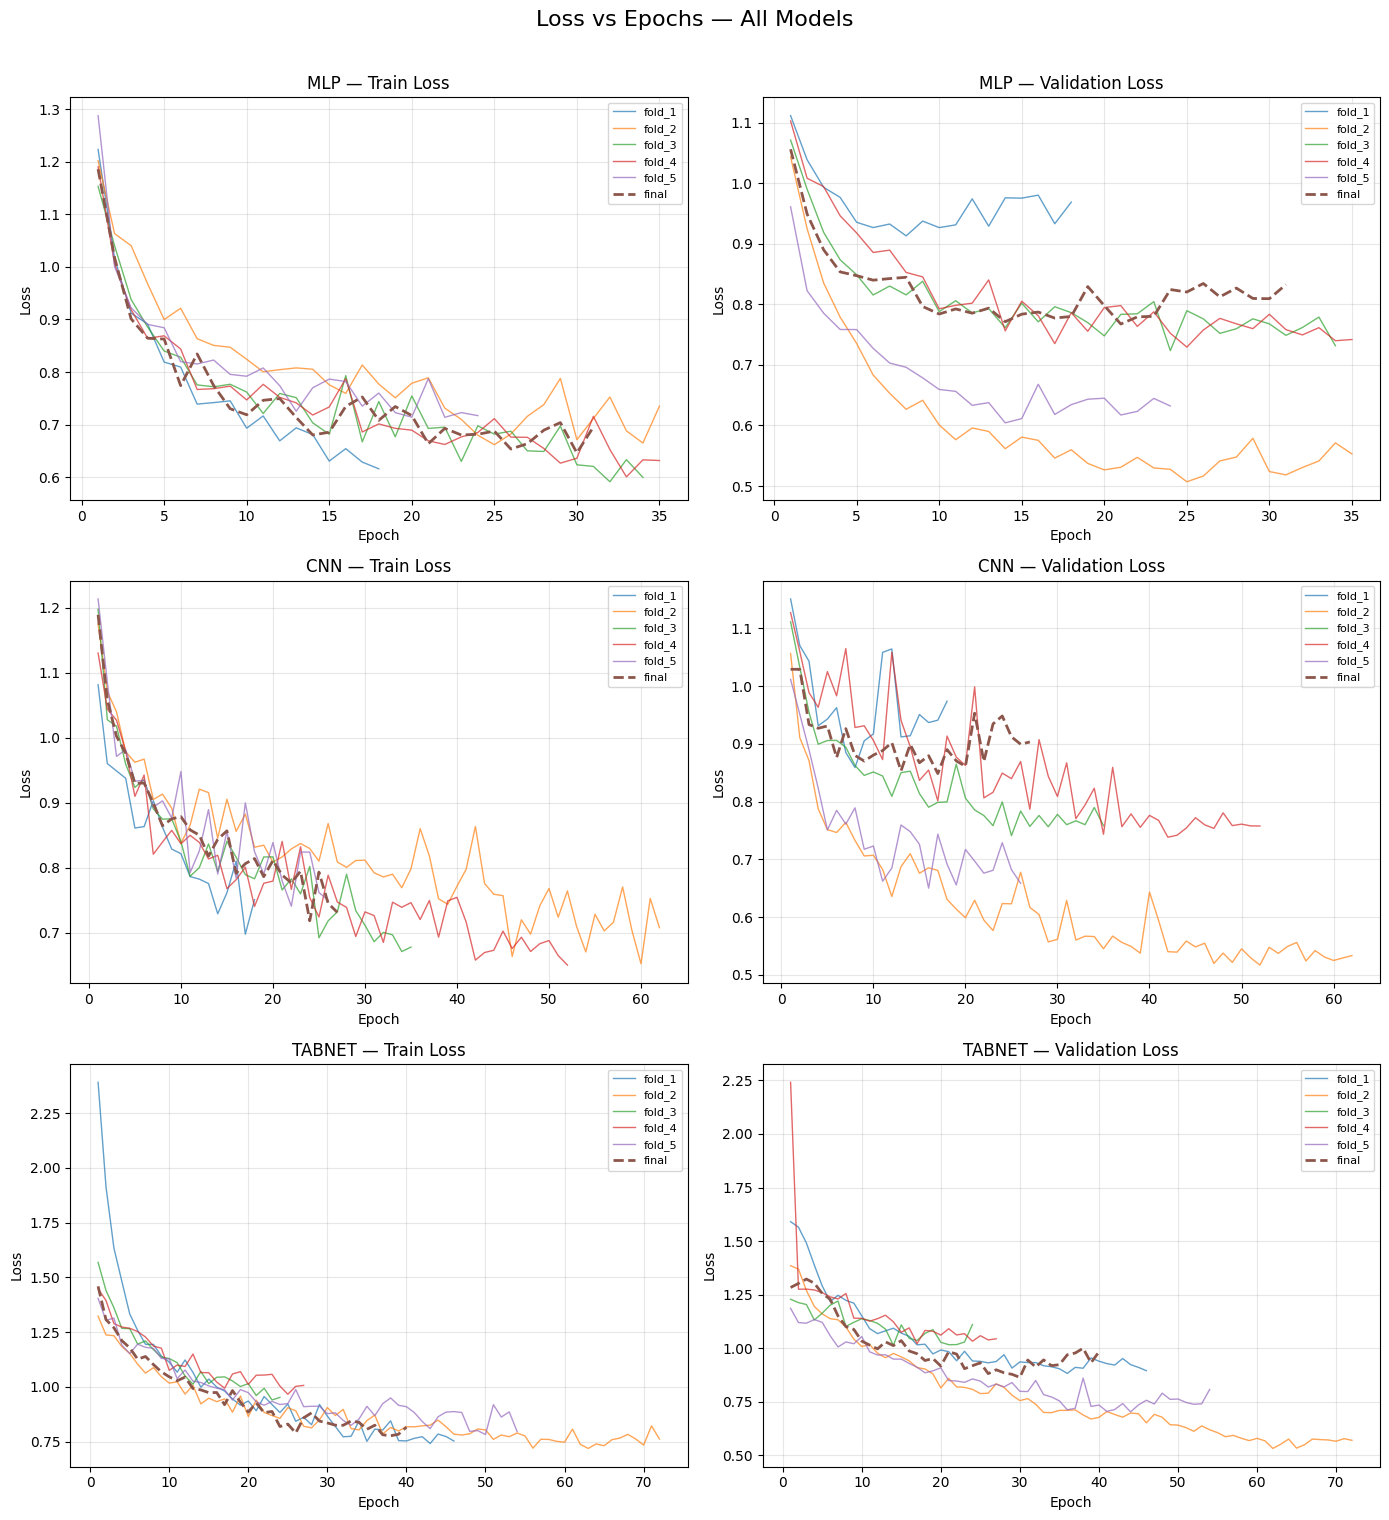

In [17]:
plot_loss_curves(model_histories, run_dir)